<a href="https://colab.research.google.com/github/nav-lak/python_library/blob/main/My_Simple_linear_regression2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [41]:
 df=pd.read_csv("/content/height-weight.csv")
 df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [42]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [43]:
df.columns

Index(['Weight', 'Height'], dtype='object')

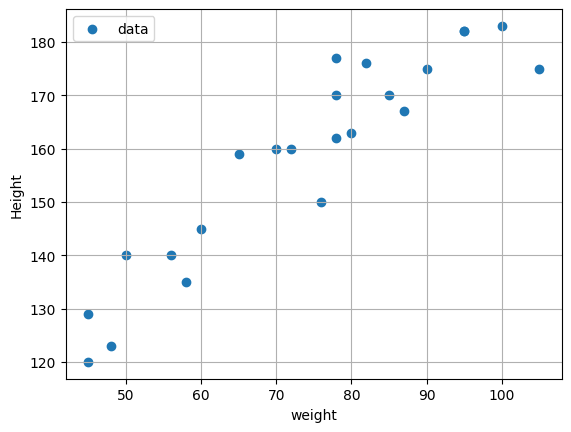

In [44]:
plt.scatter(df["Weight"],df["Height"],label="data")
plt.xlabel("weight")
plt.ylabel("Height")
plt.legend()
plt.grid()


X uses double brackets → returns DataFrame (2D)
👉 ML needs input in 2D form (rows × columns)

y uses single bracket → returns Series (1D)
👉 output/target is expected as 1D

In [45]:
#divide the data into X, y
x=df[["Weight"]]#independent feature
y=df["Height"]# dependent feature

In [46]:
 print(x)

    Weight
0       45
1       58
2       48
3       60
4       70
5       78
6       80
7       90
8       95
9       78
10      82
11      95
12     105
13     100
14      85
15      78
16      50
17      65
18      76
19      87
20      45
21      56
22      72


In [47]:
print(y)

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [49]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((16, 1), (16,), (7, 1), (7,))

In [50]:
#Scaling>> standardization >> fit_transform >>tain, transform>>test

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [52]:
#Always perform scaling after train test split
#y/target variable should not be scaled
#avoid scaling categorical features
X_train = scaler.fit_transform(X_train) #for train data use fit_transform
X_test = scaler.transform(X_test) #for test use only transform as it is representative of unknown data>>

In [53]:
X_train

array([[-0.33596868],
       [-1.6647437 ],
       [ 0.0264245 ],
       [ 0.26801996],
       [ 0.8720086 ],
       [-1.06075505],
       [ 0.57001428],
       [-1.84594029],
       [ 0.14722223],
       [-0.21517095],
       [-1.18155278],
       [ 0.14722223],
       [ 1.17400292],
       [ 1.77799157],
       [ 1.17400292],
       [ 0.14722223]])

In [54]:
X_test

array([[-1.84594029],
       [-0.637963  ],
       [-0.93995732],
       [ 1.47599724],
       [ 0.69081201],
       [-1.54394597],
       [ 0.38881769]])

<Axes: ylabel='Count'>

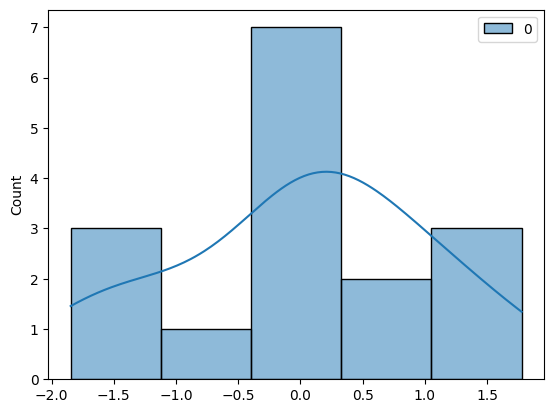

In [55]:
import seaborn as sns
sns.histplot(X_train,kde=True)

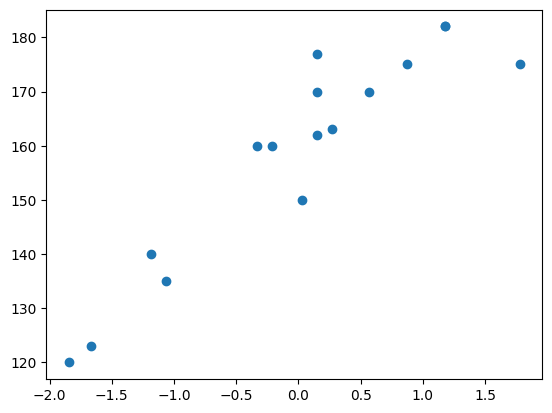

In [56]:
#scaling is optional >> why? it doesn't affect the distribution of data

# y axis will be same  because we are sacle only  x- axis data
plt.scatter(X_train, y_train)

In [57]:
#model training
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print("The slope or coef of model is", model.coef_)
print("The intercept of the model is", model.intercept_)

The slope or coef of model is [17.96866211]
The intercept of the model is 159.0


In [60]:
#prediction of train data
y_pred=model.predict(X_test)
y_pred

array([125.83092269, 147.53665835, 142.11022444, 185.52169576,
       171.41296758, 131.25735661, 165.98653367])

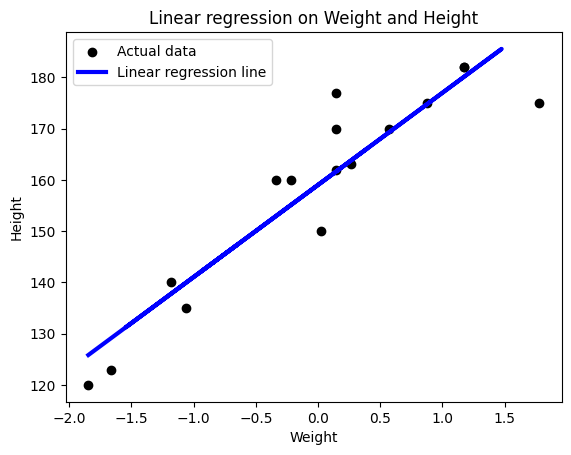

In [62]:
#visualise the result
plt.scatter(X_train, y_train, color = 'black', label = 'Actual data')
plt.plot(X_test, y_pred, color = 'blue', linewidth = 3, label = "Linear regression line")
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Linear regression on Weight and Height")
plt.legend()
plt.show()

In [63]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print(mape * 100)

3.944847534626557


In [65]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.850577349729853

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse, mae, rmse)

50.33408704814381 6.173281083006771 7.09465200331516
